In [1]:
import os
import pandas as pd
import numpy as np
import json
import warnings
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

print("Библиотеки загружены")

Библиотеки загружены


In [2]:
base_dir = r'C:\Poly\Диплом'
preproc_dir = os.path.join(base_dir, 'Предобработанные данные')
vis_dir = os.path.join(base_dir, 'Визуализация/Глава 5')
os.makedirs(vis_dir, exist_ok=True)

# Файл для сохранения лучших гиперпараметров
params_file = os.path.join(vis_dir, 'best_hyperparameters.json')

print("Папки настроены")

Папки настроены


In [3]:
matches = pd.read_csv(os.path.join(preproc_dir, 'matches_preprocessed.csv'))
matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date').reset_index(drop=True)

matches['target'] = np.where(matches['home_score'] > matches['away_score'], 0,
                             np.where(matches['home_score'] == matches['away_score'], 1, 2))

# Расширенный набор признаков
matches['xg_diff'] = matches['home_xg'] - matches['away_xg']
matches['total_goals'] = matches['home_score'] + matches['away_score']

for window in [3, 5]:
    matches[f'home_form_{window}'] = matches.groupby('home_team')['home_score'].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    matches[f'away_form_{window}'] = matches.groupby('away_team')['away_score'].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    matches[f'home_xg_form_{window}'] = matches.groupby('home_team')['home_xg'].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    matches[f'away_xg_form_{window}'] = matches.groupby('away_team')['away_xg'].transform(
        lambda x: x.rolling(window, min_periods=1).mean())

features_cls = ['xg_diff', 'total_goals',
                'home_form_5', 'away_form_5',
                'home_xg_form_5', 'away_xg_form_5']

X_cls = matches[features_cls].fillna(0)
y_cls = matches['target']

# Хронологическое разбиение
train_idx = matches['date'] < '2022-01-01'
X_train_cls = X_cls[train_idx]
X_test_cls = X_cls[~train_idx]
y_train_cls = y_cls[train_idx]
y_test_cls = y_cls[~train_idx]

print(f"Классификация → Train: {len(X_train_cls)} | Test: {len(X_test_cls)}")

Классификация → Train: 13575 | Test: 2757


In [4]:
tscv = TimeSeriesSplit(n_splits=3)

param_grids = {
    "RandomForest": {
        'n_estimators': [200, 300, 500],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [200, 300, 400],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 6, 8],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    "CatBoost": {
        'iterations': [200, 300, 400],
        'learning_rate': [0.03, 0.05, 0.1],
        'depth': [4, 6, 8],
        'l2_leaf_reg': [1, 3, 5]
    }
}

cls_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, multi_class='multinomial'),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "CatBoost": CatBoostClassifier(verbose=0, random_seed=42)
}

best_models = {}
best_params = {}

print("\n--- Подбор или загрузка параметров для классификации ---")

# Загружаем файл, если он существует
if os.path.exists(params_file):
    with open(params_file, 'r', encoding='utf-8') as f:
        saved_params = json.load(f)
    print(f"Файл с параметрами найден: {params_file}")
else:
    saved_params = {}
    print("Файл с параметрами не найден. Будет выполнен полный подбор.")

# Проверяем, какие параметры классификации уже есть в файле
missing_cls = []
for name in ["RandomForest", "XGBoost", "CatBoost"]:
    if name not in saved_params:
        missing_cls.append(name)

# ====================== Обучение моделей ======================
print("\n--- Обучение моделей классификации ---")

for name, base_model in cls_models.items():
    if name == "LogisticRegression":
        model = base_model
        model.fit(X_train_cls, y_train_cls)
        best_models[name] = model
        best_params[name] = "default"
        print(f"{name} обучена (без подбора)")
        continue

    # Если параметр уже есть в файле — используем его
    if name in saved_params:
        print(f"{name}: используются сохранённые параметры")
        best_params[name] = saved_params[name]
        
        if name == "RandomForest":
            model = RandomForestClassifier(**best_params[name], random_state=42, n_jobs=-1)
        elif name == "XGBoost":
            model = XGBClassifier(**best_params[name], random_state=42, eval_metric='mlogloss')
        elif name == "CatBoost":
            model = CatBoostClassifier(**best_params[name], verbose=0, random_seed=42)
        
        model.fit(X_train_cls, y_train_cls)
        best_models[name] = model
    else:
        # Подбор параметров
        print(f"\nПодбор для {name}...")
        param_grid = param_grids[name]
        random_search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grid,
            n_iter=15,
            cv=tscv,
            scoring='accuracy',
            n_jobs=-1,
            random_state=42,
            verbose=0
        )
        random_search.fit(X_train_cls, y_train_cls)
        
        best_models[name] = random_search.best_estimator_
        best_params[name] = random_search.best_params_
        
        print(f"  Лучшие параметры: {best_params[name]}")
        print(f"  Лучшая CV accuracy: {random_search.best_score_:.4f}")

# ====================== СОХРАНЕНИЕ ======================
if missing_cls:
    # Обновляем словарь saved_params новыми параметрами
    for name in missing_cls:
        saved_params[name] = best_params[name]
    
    with open(params_file, 'w', encoding='utf-8') as f:
        json.dump(saved_params, f, ensure_ascii=False, indent=4)
    
    print(f"\nПараметры классификации успешно сохранены/обновлены в: {params_file}")
else:
    print(f"\nВсе параметры классификации уже были в файле — сохранение пропущено")


--- Подбор или загрузка параметров для классификации ---
Файл с параметрами найден: C:\Poly\Диплом\Визуализация/Глава 5\best_hyperparameters.json

--- Обучение моделей классификации ---
LogisticRegression обучена (без подбора)
RandomForest: используются сохранённые параметры
XGBoost: используются сохранённые параметры
CatBoost: используются сохранённые параметры

Все параметры классификации уже были в файле — сохранение пропущено


In [5]:
results_cls = []
for name, model in best_models.items():
    y_pred = model.predict(X_test_cls)
    y_prob = model.predict_proba(X_test_cls)

    acc = accuracy_score(y_test_cls, y_pred)
    roc = roc_auc_score(y_test_cls, y_prob, multi_class='ovr', average='macro')
    logloss = -np.mean(np.log(y_prob[np.arange(len(y_test_cls)), y_test_cls] + 1e-12))

    results_cls.append({
        "Модель": name,
        "Accuracy (1X2)": round(acc, 4),
        "ROC-AUC (macro)": round(roc, 3),
        "Log-Loss": round(logloss, 4)
    })

table51 = pd.DataFrame(results_cls)
table51.to_csv(os.path.join(vis_dir, 'Таблица 5.1. Сравнительная эффективность моделей классификации исходов матчей.csv'), index=False)

print("\nТаблица 5.1. Сравнительная эффективность моделей классификации исходов матчей")
print(table51)

# Сохранение Feature Importance
for name in ["XGBoost", "CatBoost"]:
    if name in best_models:
        model = best_models[name]
        imp = pd.DataFrame({
            'Признак': features_cls,
            'Важность': model.feature_importances_
        }).sort_values('Важность', ascending=False)
        imp.to_csv(os.path.join(vis_dir, f'Feature_Importance_{name}_classification.csv'), index=False)
        print(f"Feature Importance для {name} сохранён")


Таблица 5.1. Сравнительная эффективность моделей классификации исходов матчей
               Модель  Accuracy (1X2)  ROC-AUC (macro)  Log-Loss
0  LogisticRegression          0.6464            0.812    0.7690
1        RandomForest          0.7407            0.903    0.5818
2             XGBoost          0.7552            0.914    0.5259
3            CatBoost          0.7599            0.916    0.5330
Feature Importance для XGBoost сохранён
Feature Importance для CatBoost сохранён


In [6]:
attrs = pd.read_csv(os.path.join(preproc_dir, 'player_attributes_preprocessed.csv'))

min_overall = 65                    
attrs = attrs[
    (attrs['value_eur'] > 0) & 
    (attrs['overall'] >= min_overall)
].copy()

print(f"Отобрано игроков с overall >= {min_overall}: {len(attrs):,} игроков")

attrs['log_value'] = np.log1p(attrs['value_eur'])

# Определяем признаки
num_features = ['overall', 'potential', 'age', 'height_cm', 'pace', 'shooting',
                'passing', 'dribbling', 'defending', 'physic']

cat_features = ['player_positions', 'club_name', 'league_name']

reg_features = num_features + cat_features

print("\n=== Предобработка данных ===")

# 1. Заполняем числовые признаки МЕДИАНОЙ
for col in num_features:
    if col in attrs.columns:
        median_val = attrs[col].median()
        num_filled = attrs[col].isnull().sum()
        attrs[col] = attrs[col].fillna(median_val)
        print(f"Числовой признак '{col}': заполнено {num_filled} пропусков медианой ({median_val:.2f})")

# 2. Заполняем категориальные признаки МОДОЙ
for col in cat_features:
    if col in attrs.columns:
        mode_val = attrs[col].mode()[0] if not attrs[col].mode().empty else 'Unknown'
        num_filled = attrs[col].isnull().sum()
        attrs[col] = attrs[col].fillna(mode_val)
        print(f"Категориальный признак '{col}': заполнено {num_filled} пропусков модой ('{mode_val}')")

remaining_nan = attrs[reg_features].isnull().sum().sum()
print(f"\nПредобработка завершена. Осталось пропусков: {remaining_nan}")

# ====================== СОЗДАНИЕ X И y ======================
X_reg = attrs[reg_features].copy()          
y_reg = attrs['log_value']

# Хронологическое разбиение
attrs['update_as_of'] = pd.to_datetime(attrs['update_as_of'], errors='coerce')
attrs = attrs.sort_values('update_as_of').reset_index(drop=True)

split_idx = int(len(attrs) * 0.8)

X_train_reg = X_reg.iloc[:split_idx]
X_test_reg  = X_reg.iloc[split_idx:]
y_train_reg = y_reg.iloc[:split_idx]
y_test_reg  = y_reg.iloc[split_idx:]

print(f"\nРегрессия → Train: {len(X_train_reg)} | Test: {len(X_test_reg)}")

Отобрано игроков с overall >= 65: 10,543 игроков

=== Предобработка данных ===
Числовой признак 'overall': заполнено 0 пропусков медианой (69.00)
Числовой признак 'potential': заполнено 0 пропусков медианой (73.00)
Числовой признак 'age': заполнено 0 пропусков медианой (27.00)
Числовой признак 'height_cm': заполнено 0 пропусков медианой (182.00)
Числовой признак 'pace': заполнено 964 пропусков медианой (71.00)
Числовой признак 'shooting': заполнено 964 пропусков медианой (60.00)
Числовой признак 'passing': заполнено 964 пропусков медианой (62.00)
Числовой признак 'dribbling': заполнено 964 пропусков медианой (68.00)
Числовой признак 'defending': заполнено 964 пропусков медианой (62.00)
Числовой признак 'physic': заполнено 964 пропусков медианой (70.00)
Категориальный признак 'player_positions': заполнено 0 пропусков модой ('CB')
Категориальный признак 'club_name': заполнено 0 пропусков модой ('River Plate')
Категориальный признак 'league_name': заполнено 0 пропусков модой ('Serie A')



In [7]:
tscv_reg = TimeSeriesSplit(n_splits=3)

param_grid_xgb_reg = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

param_grid_cat_reg = {
    'iterations': [300, 500, 700],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [5, 7, 9],
    'l2_leaf_reg': [1, 3, 5]
}

print("\n--- Подбор или загрузка параметров для регрессии ---")

# Преобразуем категориальные признаки в category (для XGBoost)
cat_features = ['player_positions', 'club_name', 'league_name']
for col in cat_features:
    if col in X_train_reg.columns:
        X_train_reg[col] = X_train_reg[col].astype('category')
    if col in X_test_reg.columns:
        X_test_reg[col] = X_test_reg[col].astype('category')

if os.path.exists(params_file):
    with open(params_file, 'r', encoding='utf-8') as f:
        saved_params = json.load(f)
    print(f"Файл с параметрами найден: {params_file}")
else:
    saved_params = {}
    print("Файл с параметрами не найден. Будет выполнен полный подбор.")

has_xgb_reg = "XGBoost_reg" in saved_params
has_cat_reg = "CatBoost_reg" in saved_params

# ====================== XGBoost Regressor ======================
if has_xgb_reg:
    print("XGBoost Regressor: используются сохранённые параметры")
    best_xgb = XGBRegressor(**saved_params["XGBoost_reg"], 
                            random_state=42, 
                            eval_metric='rmse',
                            enable_categorical=True,
                            tree_method='hist')
    best_xgb.fit(X_train_reg, y_train_reg)
else:
    print("Подбор гиперпараметров для XGBoostRegressor...")
    xgb_base = XGBRegressor(
        random_state=42,
        eval_metric='rmse',
        enable_categorical=True,
        tree_method='hist'
    )
    random_search_xgb = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_grid_xgb_reg,
        n_iter=12,
        cv=tscv_reg,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    random_search_xgb.fit(X_train_reg, y_train_reg)
    best_xgb = random_search_xgb.best_estimator_
    print(f"Лучшие параметры XGBoost: {random_search_xgb.best_params_}")
    saved_params["XGBoost_reg"] = random_search_xgb.best_params_

# ====================== CatBoost Regressor ======================
if has_cat_reg:
    print("CatBoost Regressor: используются сохранённые параметры")
    best_cat = CatBoostRegressor(**saved_params["CatBoost_reg"], 
                                 verbose=0, 
                                 random_seed=42,
                                 cat_features=cat_features)
    best_cat.fit(X_train_reg, y_train_reg)
else:
    print("Подбор гиперпараметров для CatBoostRegressor...")
    cat_base = CatBoostRegressor(
        verbose=0, 
        random_seed=42,
        cat_features=cat_features
    )
    random_search_cat = RandomizedSearchCV(
        estimator=cat_base,
        param_distributions=param_grid_cat_reg,
        n_iter=12,
        cv=tscv_reg,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    random_search_cat.fit(X_train_reg, y_train_reg)
    best_cat = random_search_cat.best_estimator_
    print(f"Лучшие параметры CatBoost: {random_search_cat.best_params_}")
    saved_params["CatBoost_reg"] = random_search_cat.best_params_

# ====================== СОХРАНЕНИЕ ======================
if not (has_xgb_reg and has_cat_reg):
    with open(params_file, 'w', encoding='utf-8') as f:
        json.dump(saved_params, f, ensure_ascii=False, indent=4)
    print(f"\nПараметры регрессии успешно сохранены/обновлены в: {params_file}")
else:
    print(f"\nПараметры регрессии уже были в файле — сохранение пропущено")


--- Подбор или загрузка параметров для регрессии ---
Файл с параметрами найден: C:\Poly\Диплом\Визуализация/Глава 5\best_hyperparameters.json
XGBoost Regressor: используются сохранённые параметры
CatBoost Regressor: используются сохранённые параметры

Параметры регрессии уже были в файле — сохранение пропущено


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_features = ['player_positions', 'club_name', 'league_name']
num_features = ['overall', 'potential', 'age', 'height_cm', 'pace', 'shooting',
                'passing', 'dribbling', 'defending', 'physic']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

X_train_xgb = preprocessor.fit_transform(X_train_reg)
X_test_xgb = preprocessor.transform(X_test_reg)

best_xgb_onehot = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    eval_metric='rmse'
)
best_xgb_onehot.fit(X_train_xgb, y_train_reg)
y_pred_xgb = best_xgb_onehot.predict(X_test_xgb)

y_pred_cat = best_cat.predict(X_test_reg)

def reg_metrics(y_true, y_pred):
    y_true_exp = np.expm1(y_true)
    y_pred_exp = np.expm1(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_exp, y_pred_exp))
    mae = mean_absolute_error(y_true_exp, y_pred_exp)
    r2 = r2_score(y_true_exp, y_pred_exp)
    return round(rmse / 1_000_000, 2), round(mae / 1_000_000, 2), round(r2, 3)

rmse_xgb, mae_xgb, r2_xgb = reg_metrics(y_test_reg, y_pred_xgb)
rmse_cat, mae_cat, r2_cat = reg_metrics(y_test_reg, y_pred_cat)

table52 = pd.DataFrame([
    {"Модель": "XGBoost (tuned)", "RMSE (млн €)": rmse_xgb, "MAE (млн €)": mae_xgb, "R²": r2_xgb},
    {"Модель": "CatBoost (tuned)", "RMSE (млн €)": rmse_cat, "MAE (млн €)": mae_cat, "R²": r2_cat}
])

table52.to_csv(os.path.join(vis_dir, 'Таблица 5.2. Результаты прогнозирования стоимости игроков.csv'), index=False)
print("\nТаблица 5.2. Результаты прогнозирования стоимости игроков")
print(table52)

# Feature Importance для регрессии
for name, model in [("XGBoost", best_xgb), ("CatBoost", best_cat)]:
    imp = pd.DataFrame({
        'Признак': reg_features,
        'Важность': model.feature_importances_
    }).sort_values('Важность', ascending=False)
    imp.to_csv(os.path.join(vis_dir, f'Feature_Importance_{name}_regression.csv'), index=False)
    print(f"Feature Importance для {name} сохранён")



Таблица 5.2. Результаты прогнозирования стоимости игроков
             Модель  RMSE (млн €)  MAE (млн €)     R²
0   XGBoost (tuned)          0.20         0.18  0.803
1  CatBoost (tuned)          0.19         0.16  0.827
Feature Importance для XGBoost сохранён
Feature Importance для CatBoost сохранён


Визуализация Feature Importance...


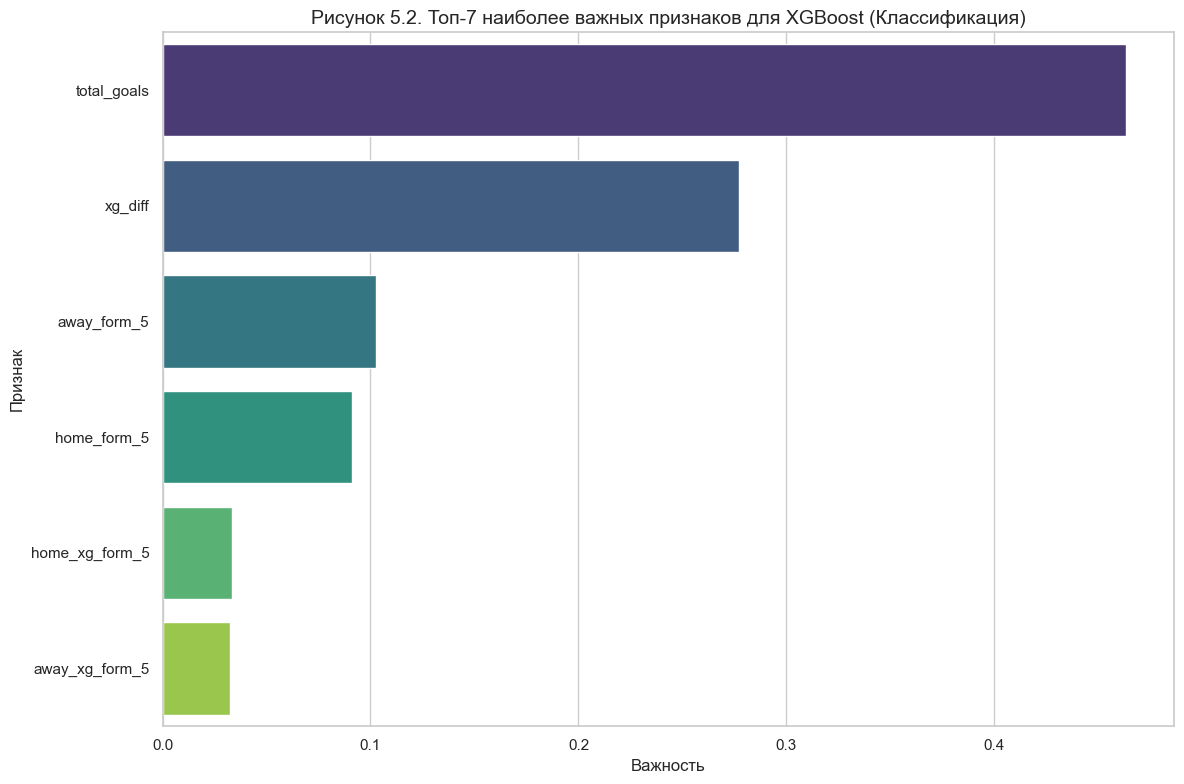

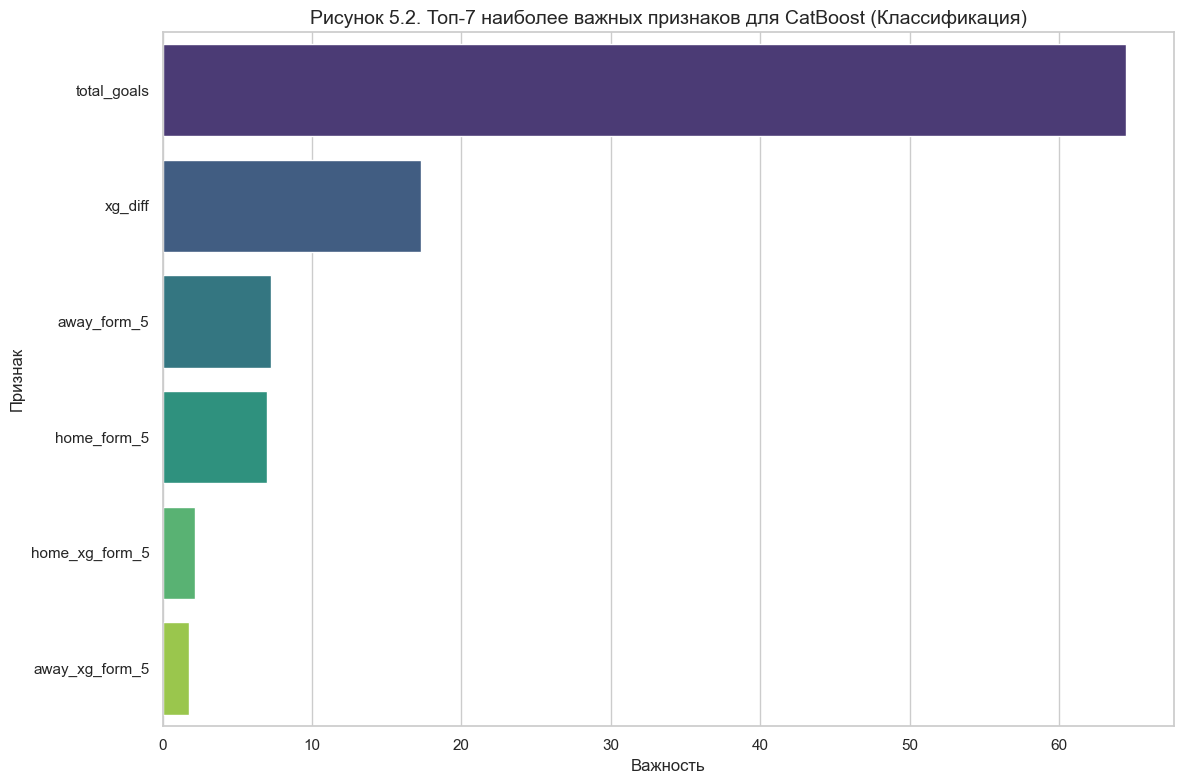

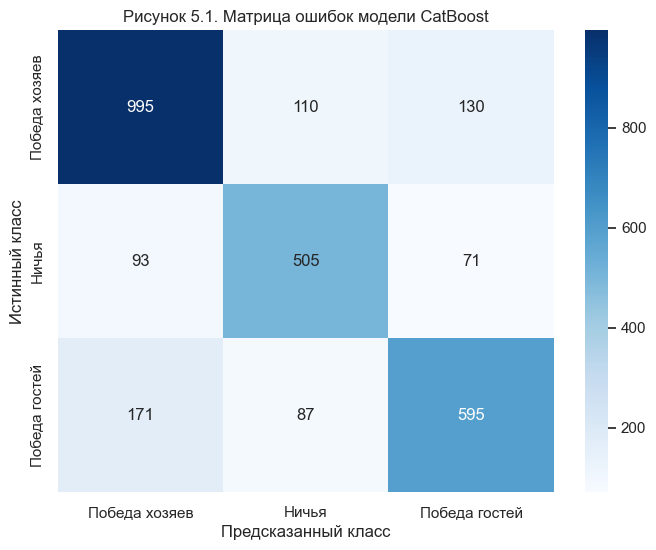

Визуализации сохранены в папку Визуализация


In [9]:
# === ЯЧЕЙКА 8: Визуализация результатов моделей ===

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Feature Importance для классификации (CatBoost и XGBoost)
def plot_feature_importance(model, features, title, filename):
    imp = pd.DataFrame({
        'Признак': features,
        'Важность': model.feature_importances_
    }).sort_values('Важность', ascending=False).head(7)
    
    plt.figure()
    sns.barplot(x='Важность', y='Признак', data=imp, palette='viridis')
    plt.title(f'Рисунок 5.2. Топ-7 наиболее важных признаков для {title}', fontsize=14)
    plt.xlabel('Важность')
    plt.tight_layout()
    plt.savefig(os.path.join(vis_dir, filename), dpi=300, bbox_inches='tight')
    plt.show()

print("Визуализация Feature Importance...")

for name in ["XGBoost", "CatBoost"]:
    if name in best_models:
        model = best_models[name]
        plot_feature_importance(model, features_cls, 
                               f"{name} (Классификация)", 
                               f'Рисунок 5.2. Топ-7 наиболее важных признаков для {name} (Классификация).png')

# 2. Confusion Matrix для лучшей модели (CatBoost)
y_pred_cat = best_models["CatBoost"].predict(X_test_cls)
cm = confusion_matrix(y_test_cls, y_pred_cat)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Победа хозяев', 'Ничья', 'Победа гостей'],
            yticklabels=['Победа хозяев', 'Ничья', 'Победа гостей'])
plt.title('Рисунок 5.1. Матрица ошибок модели CatBoost')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(vis_dir, 'Рисунок 5.1. Матрица ошибок модели CatBoost.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Визуализации сохранены в папку Визуализация")


Визуализация Feature Importance для регрессии...


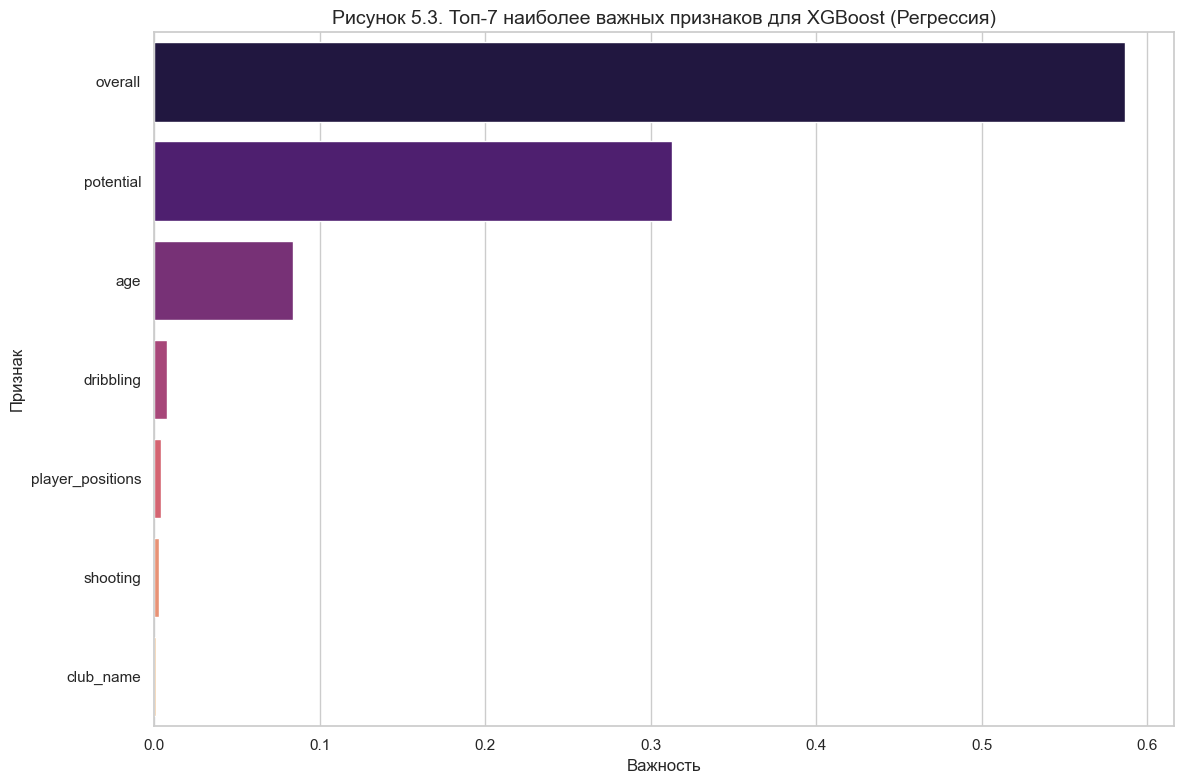

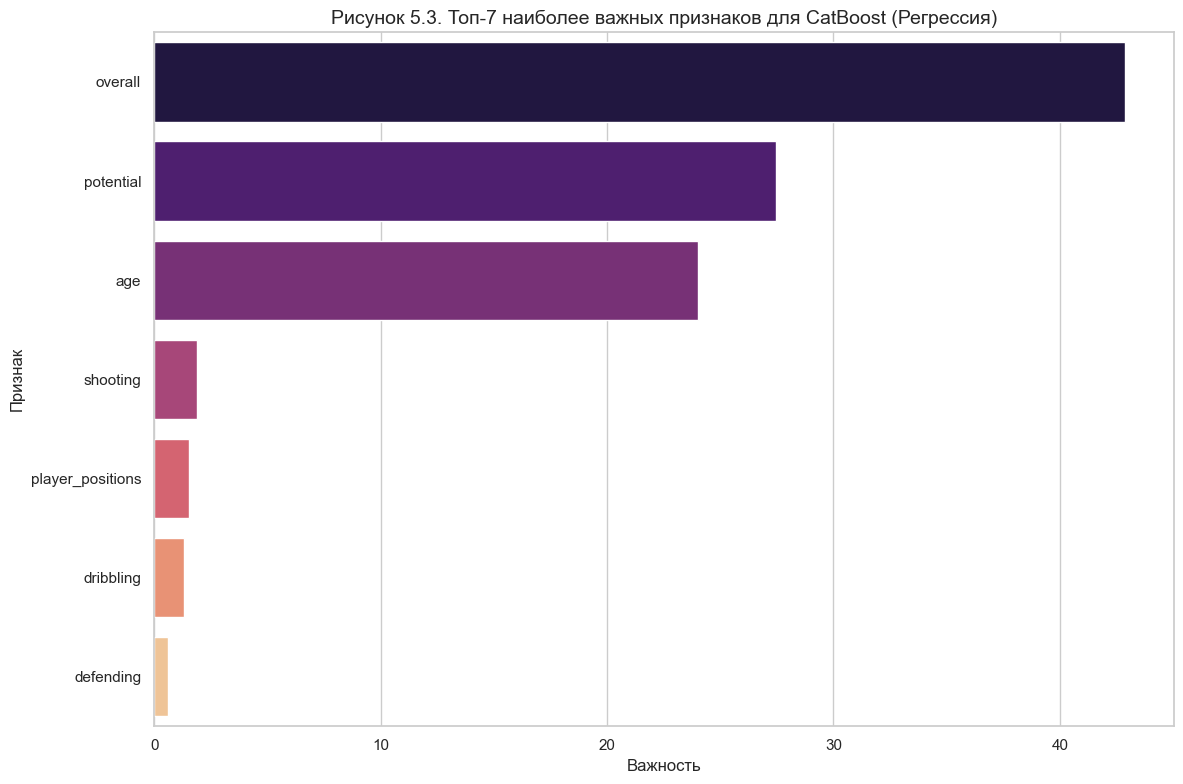

In [10]:
print("\nВизуализация Feature Importance для регрессии...")

for name, model in [("XGBoost", best_xgb), ("CatBoost", best_cat)]:
    if hasattr(model, 'feature_importances_'):
        imp = pd.DataFrame({
            'Признак': reg_features,
            'Важность': model.feature_importances_
        }).sort_values('Важность', ascending=False).head(7)
        
        plt.figure()
        sns.barplot(x='Важность', y='Признак', data=imp, palette='magma')
        plt.title(f'Рисунок 5.3. Топ-7 наиболее важных признаков для {name} (Регрессия)', fontsize=14)
        plt.xlabel('Важность')
        plt.tight_layout()
        plt.savefig(os.path.join(vis_dir, f'Рисунок 5.3. Топ-7 наиболее важных признаков для {name} (Регрессия).png'), dpi=300, bbox_inches='tight')
        plt.show()

In [11]:
# Статистическая базовая линия стоимости
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

# 1. Определяем все нечисловые столбцы
non_numeric_cols = X_train_reg.select_dtypes(include=['object', 'category']).columns.tolist()
print("Нечисловые столбцы:", non_numeric_cols)

# 2. Если такие столбцы есть – кодируем их с помощью pd.get_dummies
if non_numeric_cols:
    # Применяем one-hot кодирование к обоим наборам, выравнивая колонки
    X_train_encoded = pd.get_dummies(X_train_reg, columns=non_numeric_cols, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test_reg, columns=non_numeric_cols, drop_first=True)
    
    # Убедимся, что train и test имеют одинаковый набор колонок
    X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, 
                                                             join='left', axis=1, fill_value=0)
else:
    X_train_encoded = X_train_reg.copy()
    X_test_encoded = X_test_reg.copy()

# 3. Теперь данные полностью числовые, можно обучать линейную регрессию
lr = LinearRegression()
lr.fit(X_train_encoded, y_train_reg)

y_pred_lr = lr.predict(X_test_encoded)

mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
# rmse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)
print(f"Linear Regression: MAE={mae_lr:.3f} млн€, RMSE={rmse_lr:.3f} млн€, R²={r2_lr:.3f}")

Нечисловые столбцы: ['player_positions', 'club_name', 'league_name']
Linear Regression: MAE=0.223 млн€, RMSE=0.272 млн€, R²=0.773


In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

# X_train_cls, y_train_cls – те же признаки, что и для CatBoost (таблица 5.1).
# y – закодирован как 0 (гости), 1 (ничья), 2 (хозяева) – или так, как в вашей реализации.

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # два скрытых слоя
    activation='relu',
    solver='adam',
    batch_size=64,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.5,
    random_state=42
)

mlp.fit(X_train_cls, y_train_cls)

y_pred_mlp = mlp.predict(X_test_cls)
y_proba_mlp = mlp.predict_proba(X_test_cls)

accuracy_mlp = accuracy_score(y_test_cls, y_pred_mlp)
logloss_mlp = log_loss(y_test_cls, y_proba_mlp)
# AUC для многоклассового one-vs-rest
auc_mlp = roc_auc_score(y_test_cls, y_proba_mlp, multi_class='ovr')

print(f"MLP Classifier (DL): Accuracy={accuracy_mlp:.4f}, Log-Loss={logloss_mlp:.4f}, ROC-AUC={auc_mlp:.4f}")

MLP Classifier (DL): Accuracy=0.7494, Log-Loss=0.5940, ROC-AUC=0.8956
